In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset, load_from_disk, DatasetDict
from transformers import AutoProcessor, CLIPModel
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from tqdm.auto import tqdm


### 1. CONFIG

In [ ]:
DATA_DIR = Path("/home/jonas/Datasets/TikZ/DatikZ-v4")  # anpassen
DATA_DIR = Path("/home/jonas/Datasets/TikZ/benchmark-not-clean")

N_SAMPLES = None #None to use the complete dataset
N_CLUSTERS = 6
BATCH_SIZE = 128
SEED = 42

IMAGE_COL = "image" #png_image
MODEL_ID = "openai/clip-vit-base-patch32"


### 2. LOAD-DATA

In [7]:
def load_local_dataset(path: Path):
    parquet_files = sorted(path.rglob("*.parquet"))

    data = load_dataset(
        "parquet",
        data_files=[str(p) for p in parquet_files],
    )

    return data["train"]


ds = load_local_dataset(DATA_DIR)
print(ds)
print(ds.column_names)


Dataset({
    features: ['caption', 'code', 'image', 'pdf', 'uri', 'origin', 'date'],
    num_rows: 167694
})
['caption', 'code', 'image', 'pdf', 'uri', 'origin', 'date']


Used images: 167,694


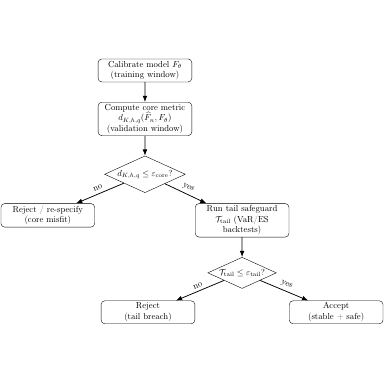

In [8]:
if N_SAMPLES is None:
    sample = ds
else:
    n = min(N_SAMPLES, len(ds))
    sample = ds.shuffle(seed=SEED).select(range(n))

print(f"Used images: {len(sample):,}")
sample[0][IMAGE_COL]


### 3. CLIP-IMAGE-EMBEDDINGS


In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = CLIPModel.from_pretrained(MODEL_ID).eval().to(device)


Device: cuda


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 93740.62it/s]


In [10]:
all_embeddings = []

for start in tqdm(range(0, len(sample), BATCH_SIZE)):
    batch = sample[start : start + BATCH_SIZE]
    images = [img.convert("RGB") for img in batch[IMAGE_COL]]

    inputs = processor(images=images, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    with torch.inference_mode():
        features = model.get_image_features(pixel_values=pixel_values).pooler_output
        features = features / features.norm(dim=-1, keepdim=True)

    all_embeddings.append(features.cpu().numpy())

embeddings = np.concatenate(all_embeddings, axis=0)
print("Embedding-Matrix:", embeddings.shape)

np.save("datikz_clip_embeddings.npy", embeddings)


100%|██████████| 1311/1311 [07:10<00:00,  3.05it/s]


Embedding-Matrix: (167694, 512)


### 4. PCA and Clustering
PCA reduces noise and computational effort. MiniBatchKMeans is also suitable for larger
samples.


In [11]:
n_components = min(50, embeddings.shape[0] - 1, embeddings.shape[1])

pca = PCA(n_components=n_components, random_state=SEED)
X = pca.fit_transform(embeddings)

clusterer = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    batch_size=1024,
    n_init=10,
    random_state=SEED,
)
labels = clusterer.fit_predict(X)

print("PCA-Variance:", round(pca.explained_variance_ratio_.sum(), 3))


PCA-Variance: 0.706


### 5. Distribution of the clusters


,count,percent
cluster,,
0,30458,18.162844
1,33241,19.822415
2,21076,12.568130
3,31453,18.756187
4,28164,16.794876
5,23302,13.895548


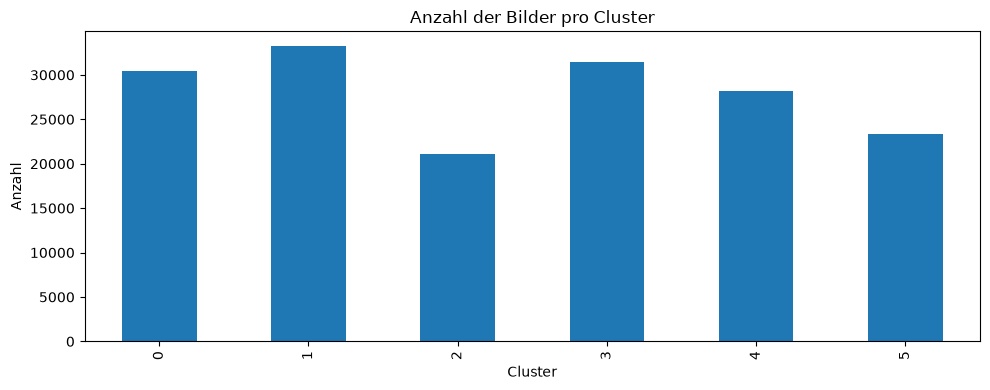

In [12]:
cluster_counts = (
    pd.Series(labels, name="cluster")
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

cluster_counts["percent"] = 100 * cluster_counts["count"] / len(labels)
display(cluster_counts)

cluster_counts["count"].plot.bar(
    figsize=(10, 4),
    title="Anzahl der Bilder pro Cluster",
    xlabel="Cluster",
    ylabel="Anzahl",
)
plt.tight_layout()
plt.show()


### 6. Two-Dimensional Overview

This representation is only a rough projection. Overlapping points
do not necessarily mean that the clusters are poor.


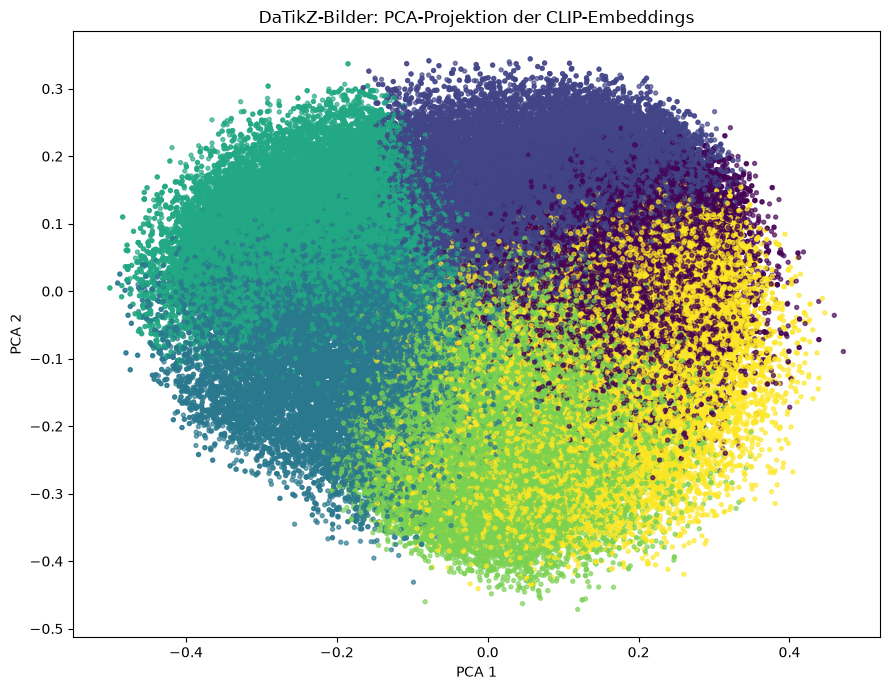

In [13]:
xy = PCA(n_components=2, random_state=SEED).fit_transform(X)

plt.figure(figsize=(9, 7))
plt.scatter(xy[:, 0], xy[:, 1], c=labels, s=8, alpha=0.65)
plt.title("DaTikZ-Bilder: PCA-Projektion der CLIP-Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()


### 6. Representative Examples per Cluster

The images shown are those with the smallest distance to the respective
cluster center. These are usually more meaningful than purely random examples.


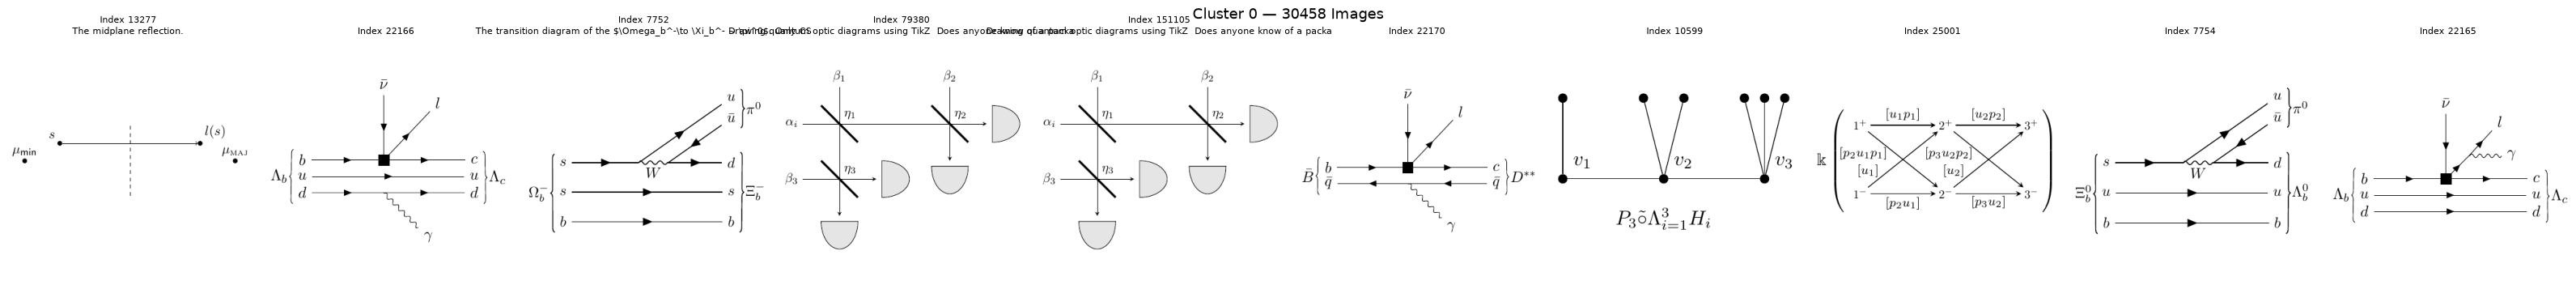

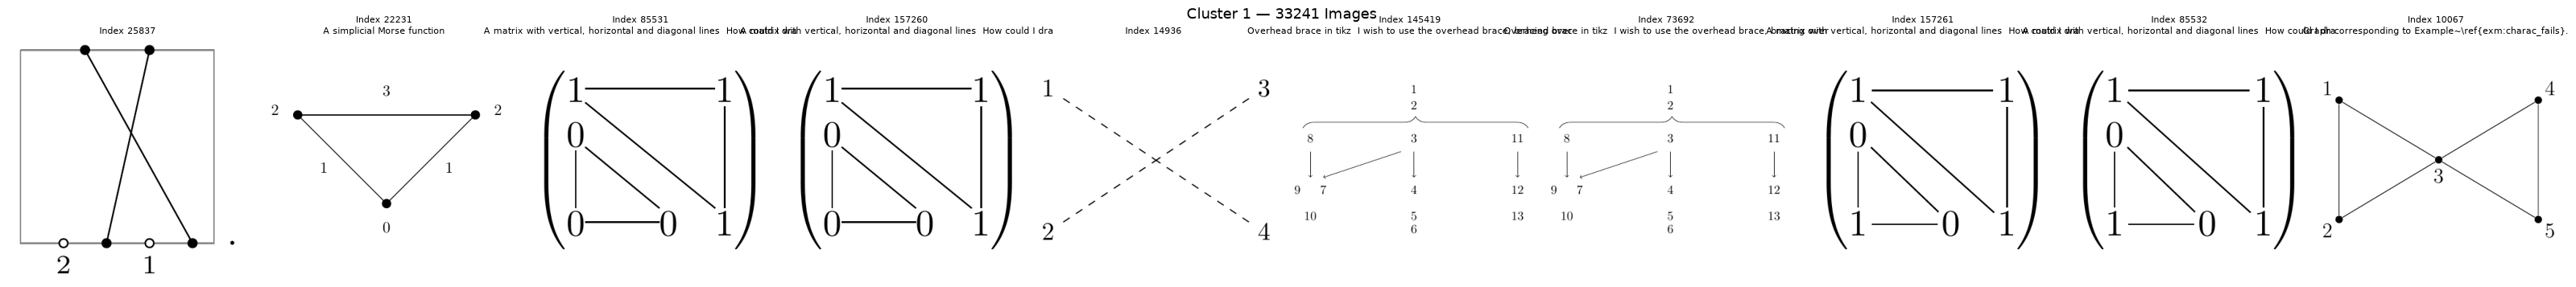

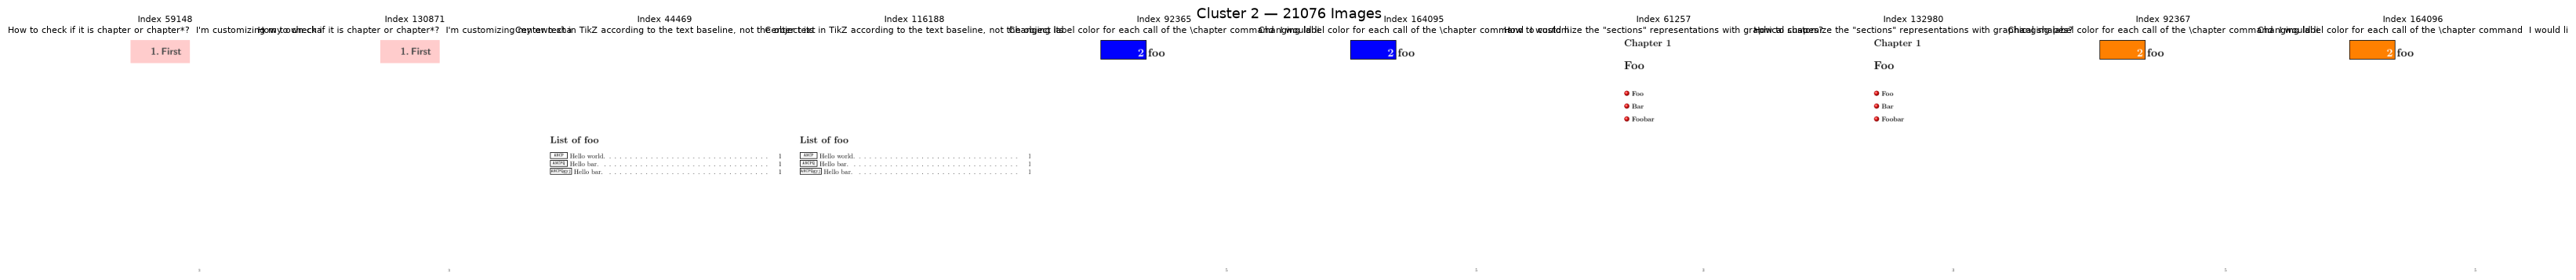

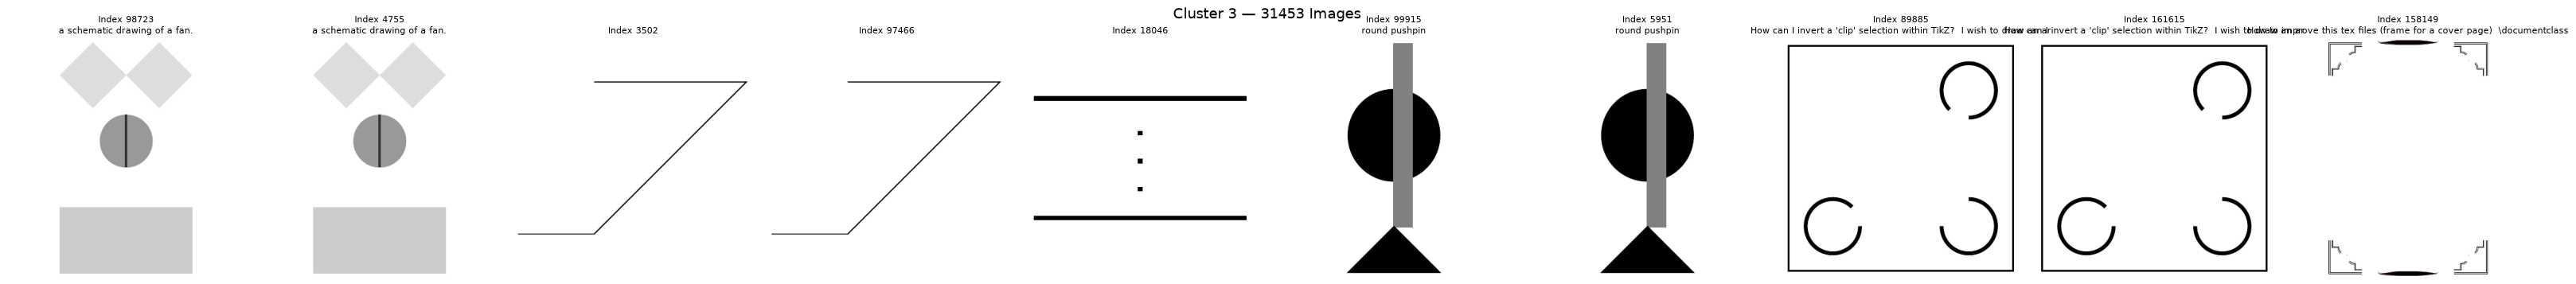

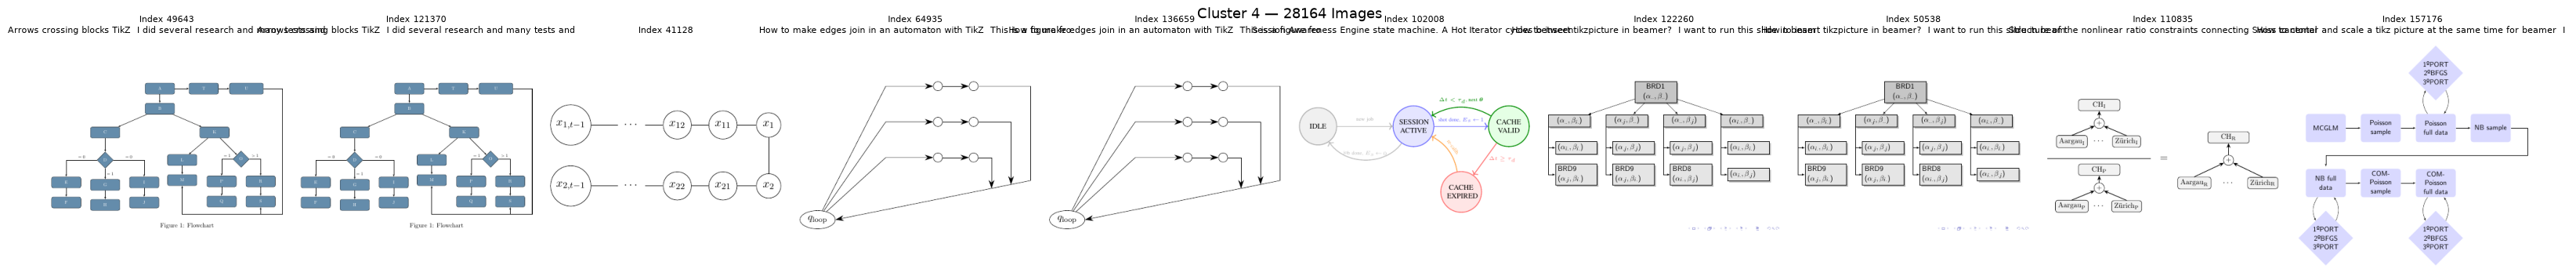

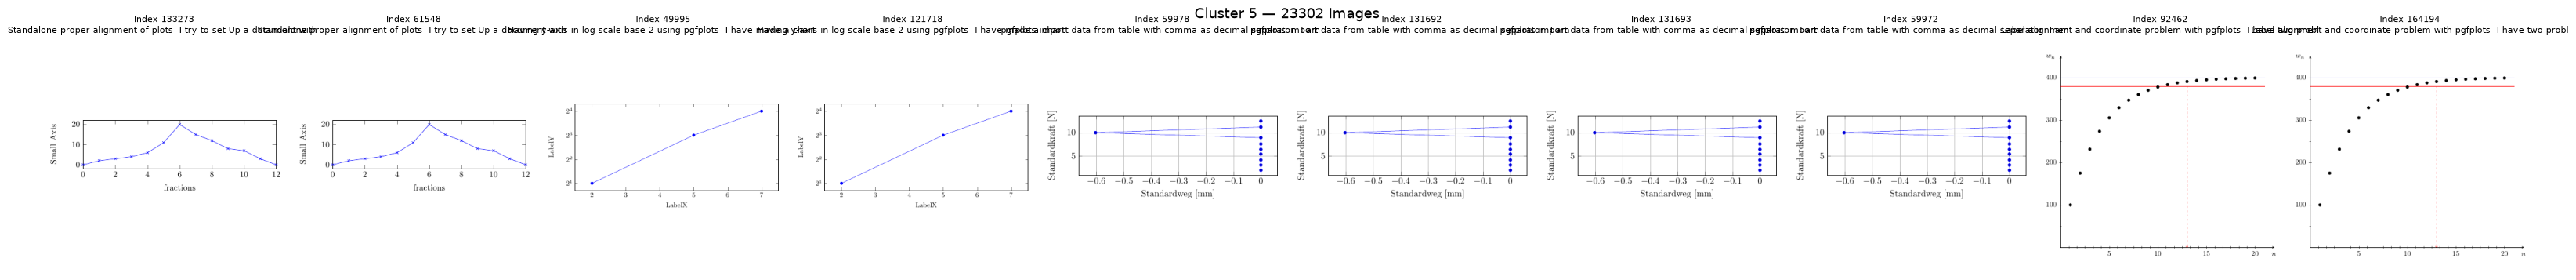

In [14]:
def show_cluster(cluster_id: int, n: int = 6):
    cluster_indices = np.where(labels == cluster_id)[0]

    if len(cluster_indices) == 0:
        print(f"Cluster {cluster_id} is empty.")
        return

    distances = np.linalg.norm(
        X[cluster_indices] - clusterer.cluster_centers_[cluster_id],
        axis=1,
    )
    selected = cluster_indices[np.argsort(distances)[:n]]

    fig, axes = plt.subplots(1, len(selected), figsize=(3.2 * len(selected), 3.6))
    axes = np.atleast_1d(axes)

    for ax, idx in zip(axes, selected):
        row = sample[int(idx)]
        ax.imshow(row[IMAGE_COL])
        ax.axis("off")

        caption = str(row.get("caption", "") or "").replace("\n", " ")
        source = str(row.get("source", "") or "")
        title = f"Index {idx}"
        if source:
            title += f" | {source}"
        if caption:
            title += "\n" + caption[:70]

        ax.set_title(title, fontsize=8, parse_math=False)

    fig.suptitle(
        f"Cluster {cluster_id} — {len(cluster_indices)} Images",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()


for cluster_id in range(N_CLUSTERS):
    show_cluster(cluster_id, n=10)


## 7. Name Clusters as Classes

After the visual review, add the names to the dictionary. The numeric
cluster IDs themselves have no semantic meaning.



In [15]:
cluster_names = {
    # Beispiele — durch deine beobachteten Klassen ersetzen:
    # 0: "Flussdiagramme",
    # 1: "Mathematische Graphen",
    # 2: "Geometrische Konstruktionen",
}

results = pd.DataFrame({
    "sample_index": np.arange(len(sample)),
    "file_id": sample["file_id"] if "file_id" in sample.column_names else [None] * len(sample),
    "source": sample["source"] if "source" in sample.column_names else [None] * len(sample),
    "cluster": labels,
})

results["class_name"] = results["cluster"].map(cluster_names)
results["class_name"] = results["class_name"].fillna(
    results["cluster"].map(lambda x: f"Cluster {x}")
)

display(results.head())
results.to_csv("datikz_cluster_assignments.csv", index=False)


,sample_index,file_id,source,cluster,class_name
0,0,None,None,4,Cluster 4
1,1,None,None,5,Cluster 5
2,2,None,None,0,Cluster 0
3,3,None,None,5,Cluster 5
4,4,None,None,0,Cluster 0


### Silhouette Score

The Silhouette Score measures how well each data point fits within its assigned cluster and how clearly it is separated from other clusters.

For each data point:

* (a) is the average distance to all other points in the same cluster.
* (b) is the average distance to the points in the nearest neighboring cluster.

The score is calculated as:

$$
s = \frac{b-a}{\max(a,b)}
$$

The resulting value ranges from **-1 to 1**:

* **Close to 1:** compact and well-separated clusters
* **Close to 0:** clusters overlap
* **Below 0:** the point may be assigned to the wrong cluster

The overall Silhouette Score is the average score across all data points.

The score is useful for comparing different numbers of clusters. For image data, it should be combined with visual inspection to check whether the clusters also represent meaningful image categories.


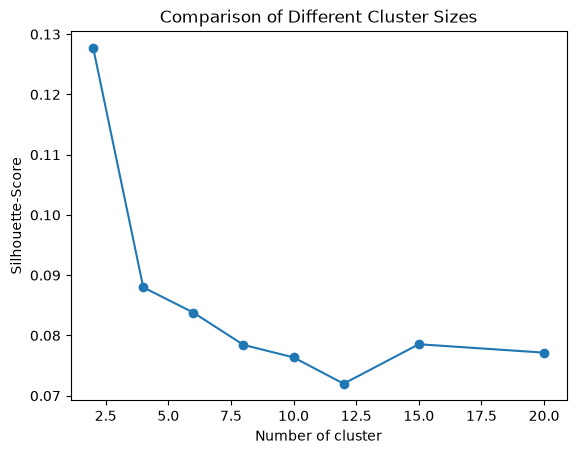

In [16]:
from sklearn.metrics import silhouette_score

scores = {}
rng = np.random.default_rng(SEED)
eval_indices = rng.choice(len(X), size=min(5_000, len(X)), replace=False)
X_eval = X[eval_indices]

for k in [2, 4, 6, 8, 10, 12, 15, 20]:
    km = MiniBatchKMeans(
        n_clusters=k,
        batch_size=1024,
        n_init=10,
        random_state=SEED,
    )
    eval_labels = km.fit_predict(X_eval)
    scores[k] = silhouette_score(X_eval, eval_labels)

pd.Series(scores, name="silhouette").plot(
    marker="o",
    xlabel="Number of cluster",
    ylabel="Silhouette-Score",
    title="Comparison of Different Cluster Sizes",
)
plt.show()
